In [1]:
import pandas as pd
import h5py
import matplotlib.pyplot as plt


## cbgim Analysis

In [2]:
# load datasets

# load 1D 
with h5py.File(
    'datasets/new_Input_bbyy_SMEFT_SM_23rdJanuary_2026.h5',
    'r'
) as f:
    cbgim_1D_df = pd.DataFrame.from_records(f['ForAnalysis/1d'][:])
    
# load 2D
with h5py.File(
    'datasets/new_Input_bbyy_SMEFT_SM_23rdJanuary_2026.h5',
    'r'
) as f:
    objects = f['ForAnalysis/2d'][:] 

weights = cbgim_1D_df['Lumi_weight']
label   = cbgim_1D_df['is_HiggsEvent']   # True = signal

In [3]:
cbgim_1D_df.head()

,DPhi_bb,Eta_jj,EventNumber,Higgs_Eta,Higgs_Mass,Higgs_Phi,Higgs_pT,LeadJet_Eta,LeadJet_M,LeadJet_Phi,...,SubLeadPhoton_Phi,SubLeadPhoton_pT,cosThetaStar,costheta1,costheta2,is_HiggsEvent,m_bbyy,nBTaggedJets,pT_jj,signed_DeltaPhi_jj
0,2.305138,-2.018553,0,-2.133709,134.749283,1.013234,108.569092,-0.652090,8.495654,-2.866707,...,1.917459,85.018845,-0.870265,0.060562,0.339152,False,388.360779,2,29.375427,3.387846
1,2.130199,-2.122291,0,-2.352877,119.822632,2.088109,80.563248,-2.148700,21.312769,-0.480589,...,0.189929,40.096840,0.396955,-0.890211,0.523630,False,314.350159,2,176.424667,0.586259
2,2.264402,2.269274,0,3.245234,122.039146,-2.823981,20.557768,2.359878,6.598670,2.044777,...,-0.473246,37.611095,-0.770758,0.681161,0.436086,False,199.478928,2,74.753830,0.357958
3,3.021186,-1.821123,0,2.608976,116.775841,-1.005800,13.737492,-1.021343,10.870246,1.738050,...,1.872487,37.369099,0.973806,-0.459972,0.715419,False,410.104034,2,44.082794,3.329032
4,1.979527,-1.126118,0,-2.401078,121.954468,2.235464,73.577911,-0.814925,6.085655,-0.410022,...,-2.282923,39.814915,-0.423949,0.624807,0.464527,False,245.735550,3,84.306290,5.941166


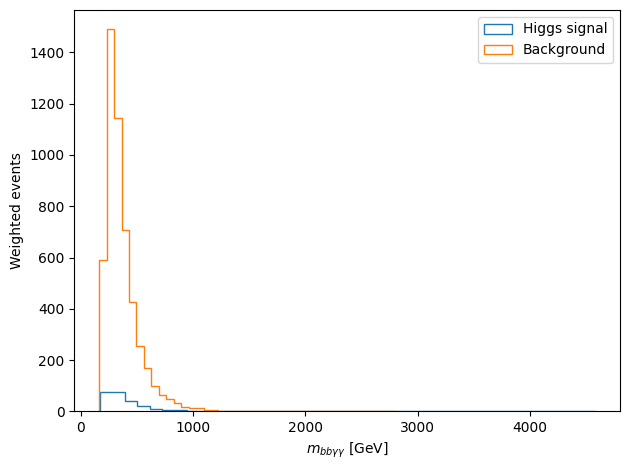

In [4]:
plt.hist(
    cbgim_1D_df.loc[label, 'm_bbyy'],
    bins=40,
    weights=weights[label],
    histtype='step',
    label='Higgs signal'
)

plt.hist(
    cbgim_1D_df.loc[~label, 'm_bbyy'],
    bins=40,
    weights=weights[~label],
    histtype='step',
    label='Background'
)

plt.xlabel(r'$m_{bb\gamma\gamma}$ [GeV]')
plt.ylabel('Weighted events')
plt.legend()
plt.tight_layout()
plt.show()


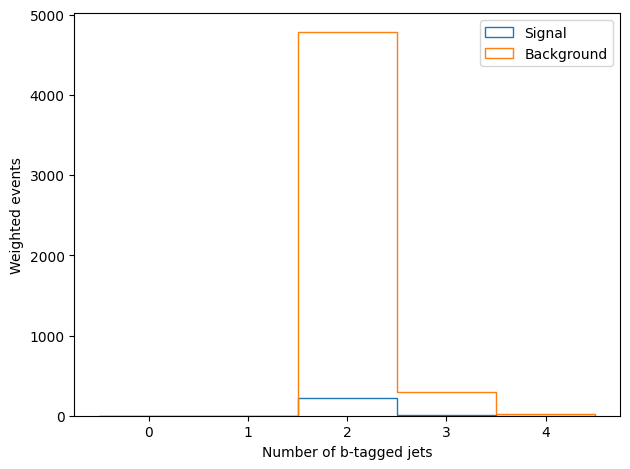

In [5]:
bins = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]

plt.hist(
    cbgim_1D_df.loc[label, 'nBTaggedJets'],
    bins=bins,
    weights=weights[label],
    histtype='step',
    label='Signal'
)

plt.hist(
    cbgim_1D_df.loc[~label, 'nBTaggedJets'],
    bins=bins,
    weights=weights[~label],
    histtype='step',
    label='Background'
)

plt.xlabel('Number of b-tagged jets')
plt.ylabel('Weighted events')
plt.legend()
plt.tight_layout()
plt.show()


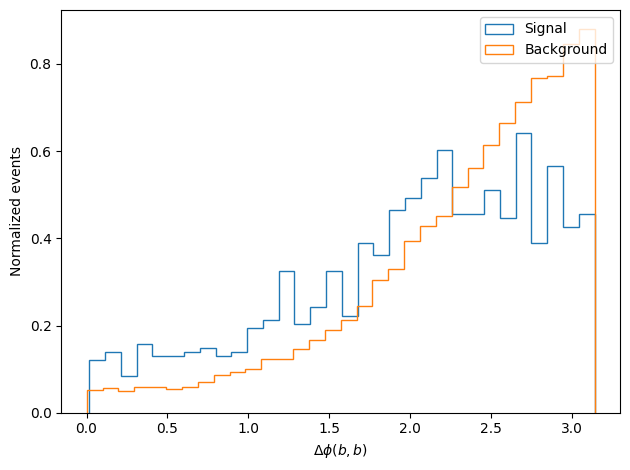

In [6]:
plt.hist(
    cbgim_1D_df.loc[label, 'DPhi_bb'],
    bins=32,
    weights=weights[label],
    histtype='step',
    density=True,
    label='Signal'
)

plt.hist(
    cbgim_1D_df.loc[~label, 'DPhi_bb'],
    bins=32,
    weights=weights[~label],
    histtype='step',
    density=True,
    label='Background'
)

plt.xlabel(r'$\Delta\phi(b,b)$')
plt.ylabel('Normalized events')
plt.legend()
plt.tight_layout()
plt.show()


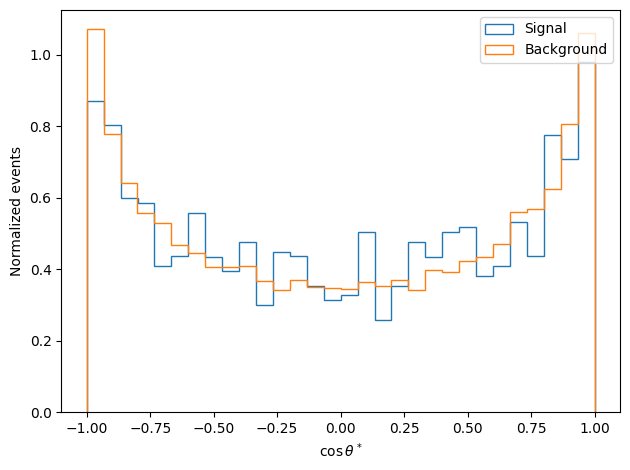

In [7]:
plt.hist(
    cbgim_1D_df.loc[label, 'cosThetaStar'],
    bins=30,
    weights=weights[label],
    histtype='step',
    density=True,
    label='Signal'
)

plt.hist(
    cbgim_1D_df.loc[~label, 'cosThetaStar'],
    bins=30,
    weights=weights[~label],
    histtype='step',
    density=True,
    label='Background'
)

plt.xlabel(r'$\cos\theta^*$')
plt.ylabel('Normalized events')
plt.legend()
plt.tight_layout()
plt.show()


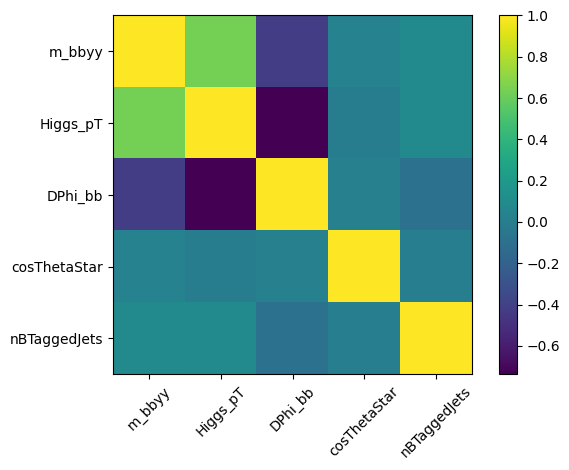

In [8]:
vars_to_check = [
    'm_bbyy',
    'Higgs_pT',
    'DPhi_bb',
    'cosThetaStar',
    'nBTaggedJets'
]

corr = cbgim_1D_df.loc[label, vars_to_check].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(vars_to_check)), vars_to_check, rotation=45)
plt.yticks(range(len(vars_to_check)), vars_to_check)
plt.tight_layout()
plt.show()
